# New section

In [ ]:
# Step 1: Install TensorFlow (if necessary)
!pip install tensorflow

# Step 2: Import necessary libraries
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

# Step 3: Mount Google Drive (You’ll need to authenticate and give Colab access to your Drive)
drive.mount('/content/drive')

# Step 4: Set your dataset directory path (Replace with your actual Google Drive path)
train_data_dir = train_data_dir = '/content/drive/MyDrive/clean_dataset'
  # Update with your actual Google Drive dataset path

# Step 5: Ensure dataset directory exists
if not os.path.exists(train_data_dir):
    print(f"Dataset directory '{train_data_dir}' does not exist. Please check the path.")
else:
    # Image dimensions
    img_height, img_width = 128, 128
    batch_size = 32

    # Data Preprocessing and Augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,  # 20% validation
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    # Training data generator
    train_generator = train_datagen.flow_from_directory(
        train_data_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        subset='training'
    )

    # Validation data generator
    validation_generator = train_datagen.flow_from_directory(
        train_data_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation'
    )

    # CNN Model Architecture
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Model Training
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=20
    )

    # Save the trained model
    model.save('/content/drive/MyDrive/smart_photo_organizer_model.h5')  # Save to Google Drive

    print("✅ Model training complete and saved as 'smart_photo_organizer_model.h5'")



Mounted at /content/drive
Found 316 images belonging to 5 classes.
Found 77 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2150 - loss: 1.5724

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 8s/step - accuracy: 0.2196 - loss: 1.5669 - val_accuracy: 0.2987 - val_loss: 1.3727
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.3431 - loss: 1.4092 - val_accuracy: 0.3896 - val_loss: 1.2665
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.4835 - loss: 1.2031 - val_accuracy: 0.4935 - val_loss: 1.1035
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.5342 - loss: 1.0938 - val_accuracy: 0.5325 - val_loss: 0.9494
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.5948 - loss: 1.0181 - val_accuracy: 0.8052 - val_loss: 0.7830
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6038 - loss: 0.8986 - val_accuracy: 0.7273 - val_loss: 0.6982
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6572 - loss: 0.7542 - val_accuracy: 0.7662 - val_loss: 0.7324
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6850 - loss: 0.7009 - val_accuracy: 0.7792 - val_loss: 0.6625
Epo

✅ Model training complete and saved as 'smart_photo_organizer_model.h5'


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.8735 - loss: 0.3462 - val_accuracy: 0.8961 - val_loss: 0.3404
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8887 - loss: 0.3295 - val_accuracy: 0.8442 - val_loss: 0.4605
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.8515 - loss: 0.3670 - val_accuracy: 0.8312 - val_loss: 0.6504
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8620 - loss: 0.3511 - val_accuracy: 0.8571 - val_loss: 0.4068
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8656 - loss: 0.3612 - val_accuracy: 0.8182 - val_loss: 0.5550
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8471 - loss: 0.4784 - val_accuracy: 0.8571 - val_loss: 0.4775
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8960 - loss: 0.3191 - val_accuracy: 0.7922 - val_loss: 0.5196
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.8640 - loss: 0.2973 - val_accuracy: 0.8571 - val_loss:

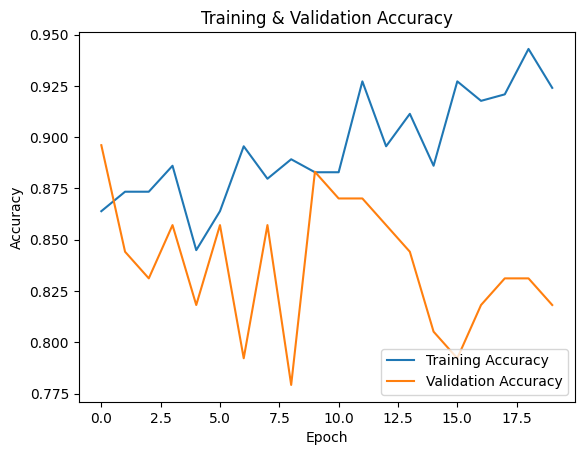

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training & Validation Accuracy')
plt.show()


In [ ]:
# Print accuracy and loss history
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['val_accuracy'])
print("Training Loss:", history.history['loss'])
print("Validation Loss:", history.history['val_loss'])


Training Accuracy: [0.8639240264892578, 0.8734177350997925, 0.8734177350997925, 0.8860759735107422, 0.844936728477478, 0.8639240264892578, 0.8955696225166321, 0.8797468543052673, 0.8892405033111572, 0.8829113841056824, 0.8829113841056824, 0.9272152185440063, 0.8955696225166321, 0.9113923907279968, 0.8860759735107422, 0.9272152185440063, 0.9177215099334717, 0.9208860993385315, 0.9430379867553711, 0.9240506291389465]
Validation Accuracy: [0.8961039185523987, 0.8441558480262756, 0.8311688303947449, 0.8571428656578064, 0.8181818127632141, 0.8571428656578064, 0.7922077775001526, 0.8571428656578064, 0.7792207598686218, 0.8831169009208679, 0.8701298832893372, 0.8701298832893372, 0.8571428656578064, 0.8441558480262756, 0.8051947951316833, 0.7922077775001526, 0.8181818127632141, 0.8311688303947449, 0.8311688303947449, 0.8181818127632141]
Training Loss: [0.3386875092983246, 0.3466489911079407, 0.3482503294944763, 0.32171741127967834, 0.4272717833518982, 0.42655640840530396, 0.3087901473045349, 0

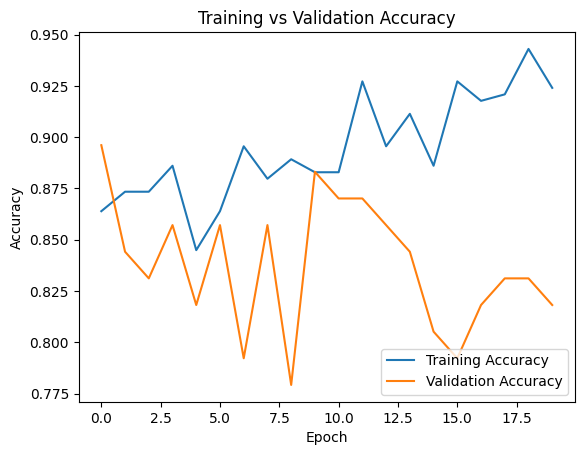

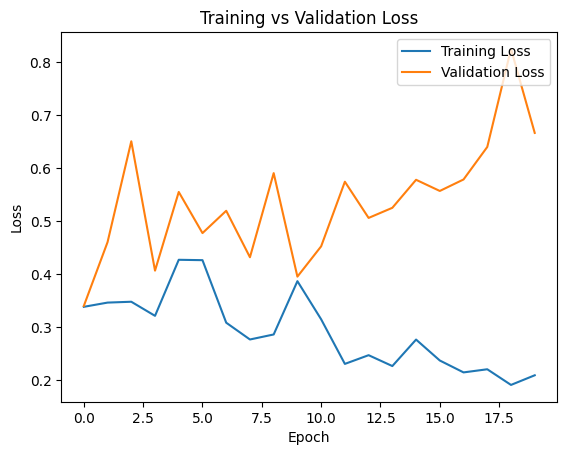

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')
plt.show()


In [ ]:
# Print last epoch accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"✅ Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc * 100:.2f}%")



✅ Final Training Accuracy: 92.41%
✅ Final Validation Accuracy: 81.82%


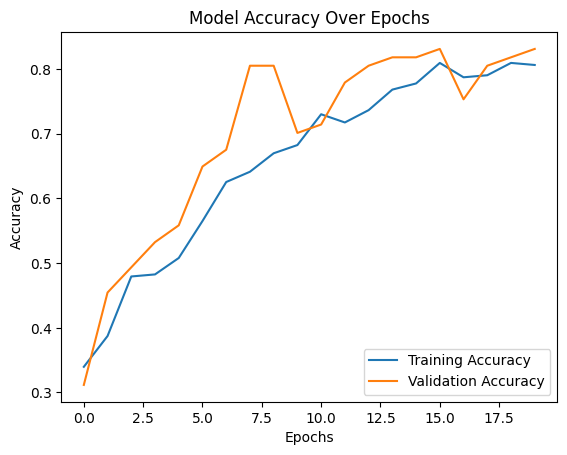

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.legend()
plt.show()


In [ ]:
import os

# Check if the model file exists
model_path = '/content/drive/MyDrive/smart_photo_organizer_model.h5'
if os.path.exists(model_path):
    print("✅ Model found!")
else:
    print("❌ Model not found. Check the path!")


✅ Model found!


In [ ]:
import os

# Check if the model file exists
model_path = '/content/drive/MyDrive/smart_photo_organizer_model.h5'
if os.path.exists(model_path):
    print("✅ Model found!")
else:
    print("❌ Model not found. Check the path!")


❌ Model not found. Check the path!


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load your saved model
model = load_model('/content/drive/MyDrive/smart_photo_organizer_model.h5')

# Load and preprocess a single image
img = image.load_img('/content/drive/MyDrive/clean_dataset/clean_dataset/selfie/test1.jpg', target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Map back to your class names
class_labels = ['selfie', 'passport', 'landscape', 'object']
print(f"Predicted Class: {class_labels[predicted_class]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Predicted Class: object


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import drive

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# Load your saved model
model = load_model('/content/drive/MyDrive/smart_photo_organizer_model.h5')

# Load and preprocess a single image
# **Updated:** Double-check this path for accuracy
img_path = '/content/drive/MyDrive/clean_dataset/selfie/test1.jpg'

# Check if the image exists
if os.path.exists(img_path):
  img = image.load_img(img_path, target_size=(128, 128))
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  # Make prediction
  prediction = model.predict(img_array)
  predicted_class = np.argmax(prediction)

  # Map back to your class names
  class_labels = ['selfie', 'passport', 'landscape', 'object']
  print(f"Predicted Class: {class_labels[predicted_class]}")
else:
  print(f"❌ Image not found at path: {img_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
❌ Image not found at path: /content/drive/MyDrive/clean_dataset/selfie/test1.jpg


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import drive
import os

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# Load your saved model
model = load_model('/content/drive/MyDrive/smart_photo_organizer_model.h5')

# Load and preprocess a single image
img_path = '/content/drive/MyDrive/clean_dataset/selfie/test1.jpg'  # Double-check the path and file name

# 1. Check file existence and case sensitivity:
if not os.path.exists(img_path):
    print(f"❌ Image not found at path: {img_path}. Check for typos and case sensitivity.")
else:
    try:
        # 2. Check image format and corruption:
        img = image.load_img(img_path, target_size=(128, 128))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make prediction
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction)

        # Map back to your class names
        class_labels = ['selfie', 'passport', 'landscape', 'object']
        print(f"Predicted Class: {class_labels[predicted_class]}")

    except Exception as e:
        print(f"❌ Error loading or processing the image: {e}")
        print("Possible reasons: incorrect format, corruption, or unsupported image type.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
❌ Image not found at path: /content/drive/MyDrive/clean_dataset/selfie/test1.jpg. Check for typos and case sensitivity.


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import drive
import os
from PIL import Image  # Import Pillow

# ... (rest of your code) ...

# Load and preprocess a single image
img_path = '/content/drive/MyDrive/clean_dataset/clean_dataset/selfie/test1.jpg'

if not os.path.exists(img_path):
    print(f"❌ Image not found at path: {img_path}. Check for typos and case sensitivity.")
else:
    try:
        # Using PIL to load the image
        img = Image.open(img_path)
        img = img.resize((128, 128))  # Resize if needed
        img_array = image.img_to_array(img) / 255.0  # Convert to NumPy array
        img_array = np.expand_dims(img_array, axis=0)

        # ... (rest of your prediction code) ...

    except Exception as e:
        print(f"❌ Error loading or processing the image: {e}")
        print("Possible reasons: incorrect format, corruption, or unsupported image type.")

❌ Image not found at path: /content/drive/MyDrive/clean_dataset/clean_dataset/selfie/test1.jpg. Check for typos and case sensitivity.


In [ ]:
# Step 1: Install TensorFlow (if not already installed)
!pip install tensorflow

# Step 2: Import necessary libraries
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from google.colab import drive

# Step 3: Mount Google Drive
drive.mount('/content/drive')

# Step 4: Set your dataset directory path
train_data_dir = '/content/drive/MyDrive/clean_dataset/clean_dataset'

# Step 5: Check for valid images and folder counts
for folder in os.listdir(train_data_dir):
    folder_path = os.path.join(train_data_dir, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"{folder}: {len(images)} valid images")

# Step 6: Image parameters and data generators
img_height, img_width = 128, 128
batch_size = 32

# Enhanced image augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Step 7: CNN Model Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),  # reduced dropout
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Optional: Save best model automatically
checkpoint = ModelCheckpoint('/content/drive/MyDrive/best_smart_photo_model.h5',
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

# Step 8: Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[checkpoint]
)

# Step 9: Save final model
model.save('/content/drive/MyDrive/final_smart_photo_model.h5')

print("✅ Training complete. Models saved to Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
object: 111 valid images
landscape: 91 valid images
passport: 99 valid images
selfie: 45 valid images
Found 278 images belonging to 4 classes.
Found 68 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2693 - loss: 1.6314

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1: val_accuracy improved from -inf to 0.27941, saving model to /content/drive/MyDrive/best_smart_photo_model.h5


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.6046 - loss: 0.9813 - val_accuracy: 0.5294 - val_loss: 1.0512
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6267 - loss: 0.8766
Epoch 5: val_accuracy improved from 0.52941 to 0.61765, saving model to /content/drive/MyDrive/best_smart_photo_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6274 - loss: 0.8789 - val_accuracy: 0.6176 - val_loss: 0.9517
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6871 - loss: 0.8005
Epoch 6: val_accuracy improved from 0.61765 to 0.73529, saving model to /content/drive/MyDrive/best_smart_photo_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.6874 - loss: 0.8018 - val_accuracy: 0.7353 - val_loss: 0.8229
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7487 - loss: 0.7008
Epoch 7: val_accuracy did not improve from 0.73529
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.7458 - loss: 0.7032 - val_accuracy: 0.6471 - val_loss: 0.8998
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7497 - loss: 0.6611
Epoch 8: val_accuracy did not improve from 0.73529
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.7474 - loss: 0.6629 - val_accuracy: 0.7206 - val_loss: 0.7400
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7765 - loss: 0.5982
Epoch 9: val_accuracy did not improve from 0.73529
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7740 - loss: 0.6011 - val_accuracy: 0.6912 - val_loss: 0.7116
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7679 - loss: 0.6053
Epoch 10: val_accuracy did not improve from 0.73529
9/9 ━━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.7140 - loss: 0.6312 - val_accuracy: 0.7794 - val_loss: 0.7314
Epoch 13/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7635 - loss: 0.5725
Epoch 13: val_accuracy did not improve from 0.77941
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7634 - loss: 0.5732 - val_accuracy: 0.7500 - val_loss: 0.9010
Epoch 14/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7477 - loss: 0.5730
Epoch 14: val_accuracy did not improve from 0.77941
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7492 - loss: 0.5703 - val_accuracy: 0.7206 - val_loss: 0.8510
Epoch 15/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7975 - loss: 0.5523
Epoch 15: val_accuracy did not improve from 0.77941
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7990 - loss: 0.5520 - val_accuracy: 0.7353 - val_loss: 0.7161
Epoch 16/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8575 - loss: 0.4734
Epoch 16: val_accuracy did not improve from 0.77941
9/9 ━━━━━━━━

✅ Training complete. Models saved to Drive.


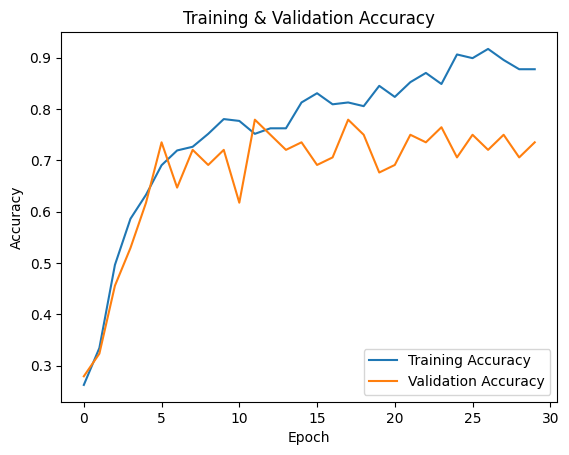

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training & Validation Accuracy')
plt.show()


In [ ]:
# Print last epoch accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"✅ Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc * 100:.2f}%")



✅ Final Training Accuracy: 87.77%
✅ Final Validation Accuracy: 73.53%
